In [1]:
import glob
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import os

import scanpy as sc
import seaborn as sns

from scroutines import basicu
from scroutines import powerplots

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tools.sm_exceptions import ValueWarning
from tqdm import tqdm

sns.set_context('talk')

In [2]:
outfigdir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/results_v1astro'

In [3]:
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/annot/gencode.vM25.genebody.bed'
df_annot = pd.read_csv(f, sep='\t', header=None)
df_annot

,0,1,2,3
0,chr1,3073253,3074322,4933401J01Rik
1,chr1,3102016,3102125,Gm26206
2,chr1,3205901,3671498,Xkr4
3,chr1,3252757,3253236,Gm18956
4,chr1,3365731,3368549,Gm37180
...,...,...,...,...
55396,chrM,13552,14070,mt-Nd6
55397,chrM,14071,14139,mt-Te
55398,chrM,14145,15288,mt-Cytb
55399,chrM,15289,15355,mt-Tt


In [4]:
!ls $outfigdir

astro_cheng_subtypes_260128.csv
NRDR_DEGs_LMM_astro_cheng22_d260129_c1.h5ad
NRDR_DEGs_LMM_astro_cheng22_d260129.h5ad
NRDR_DEGs_LMM_astro_cheng22_d260210_Astro_A.h5ad
NRDR_DEGs_LMM_astro_cheng22_d260210_Astro_B.h5ad
NRDR_DEGs_LMM_yoo25_P21_d260303_100_L45_IT_CTX_Glut_6.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_101_L45_IT_CTX_Glut_6.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_109_L23_IT_CTX_Glut_2.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_110_L23_IT_CTX_Glut_2.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_111_L23_IT_CTX_Glut_2.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_116_L23_IT_CTX_Glut_3.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_118_L23_IT_CTX_Glut_4.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_37_L6_IT_CTX_Glut_1.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_41_L6_IT_CTX_Glut_2.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_50_L6_IT_CTX_Glut_4.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_51_L6_IT_CTX_Glut_4.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_52_L6_IT_CTX_Glut_4.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_56_L5_IT_CTX_Glut_1.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_62_L5_IT_CT

In [5]:
sex_genes = ['Xist','Kdm5d','Eif2s3y','Uty','Ddx3y']

In [6]:
f_raw = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/superdupermegaRNA_hasraw_multiome_IT.h5ad'
f_lbl = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/L23_labels_gao25_to_yoo25_knn.csv' 

In [7]:
import glob

track_labels = np.sort(["_".join(os.path.basename(file).split('_')[6:])[:-4] 
                             for file in glob.glob(f'{outfigdir}/*L23_IT_CTX*.csv')])
track_labels

array(['109_L23_IT_CTX_Glut_2', '110_L23_IT_CTX_Glut_2',
       '111_L23_IT_CTX_Glut_2', '116_L23_IT_CTX_Glut_3',
       '118_L23_IT_CTX_Glut_4'], dtype='<U21')

In [8]:
filenames = [
    os.path.join(outfigdir, f'NRDR_DEGs_LMM_yoo25_P21_d260303_{track_label}.csv')
    for track_label in track_labels
]

res_list = []
for filename in filenames:
    res = pd.read_csv(filename, index_col=0)
    # remove mitochondrial and sex genes
    res = res[~res['gene'].str.startswith('mt-')]
    res = res[~res['gene'].isin(sex_genes)]
    res = res.set_index('gene')
    res_list.append(res)
    
res_list[0]


,log2fc,pval,qval,converged,P21DRa,P21DRb,P21a,P21b
gene,,,,,,,,
Xkr4,0.146112,0.502758,0.824008,True,5.955652,6.661402,5.775247,5.410131
Gm1992,-0.533011,0.152029,0.536893,True,0.100924,0.153792,0.194363,0.160985
Mrpl15,0.031781,0.712368,0.912294,True,0.128292,0.190499,0.135812,0.183449
Tcea1,0.120039,0.674600,0.901345,False,0.575940,0.534574,0.510152,0.518181
Rgs20,0.039325,0.614354,0.877306,True,1.507648,1.155408,1.194666,1.574607
...,...,...,...,...,...,...,...,...
Csf2ra,-0.226377,0.091698,0.434677,False,0.203456,0.188491,0.226404,0.244029
Vamp7,0.079529,0.944601,0.982298,True,0.085029,0.103177,0.076124,0.110223
Tmlhe,0.121944,0.661090,0.896837,False,0.241521,0.253868,0.212571,0.253517


In [9]:
df_list = []
df_sig_list = []
df_raw_list = []
idx = 2

x_th =  np.log2(1.5)
y_th = -np.log10(0.05)

q_inf = 1e-50
# z = df['max_cp10k']
# z_th = 0.1

for i, res in enumerate(res_list):
    
    
    df = res.copy()
    df['l2fc'] = res['log2fc']#[:,idx]
    df['l10q'] = -np.log10(res['qval'])#[:,idx])
    
    # converge, expressed (or not too small q)
    cond_pre = np.logical_and(res['converged'], 
                              res['qval']>q_inf)
    df_raw = df.copy()
    df = df[cond_pre]

    x = df['l2fc'].values 
    y = df['l10q'].values
    z = df['score'] = np.abs(df['l2fc']).rank(pct=True)+df['l10q'].rank(pct=True)
    
    cond_sig = np.all([np.abs(x) > x_th, 
                       y > y_th, 
                       # z > z_th, 
                      ], axis=0)

    print(np.sum(cond_sig))
    df_sig = df[cond_sig]
    df_sig = df_sig.sort_values('l10q', ascending=False)
    df_sig['direction'] = np.where(df_sig['l2fc']>0, 'up', 'down')
    
    df_list.append(df)
    df_sig_list.append(df_sig)
    df_raw_list.append(df_raw)


80
182
131
12
42


/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwa

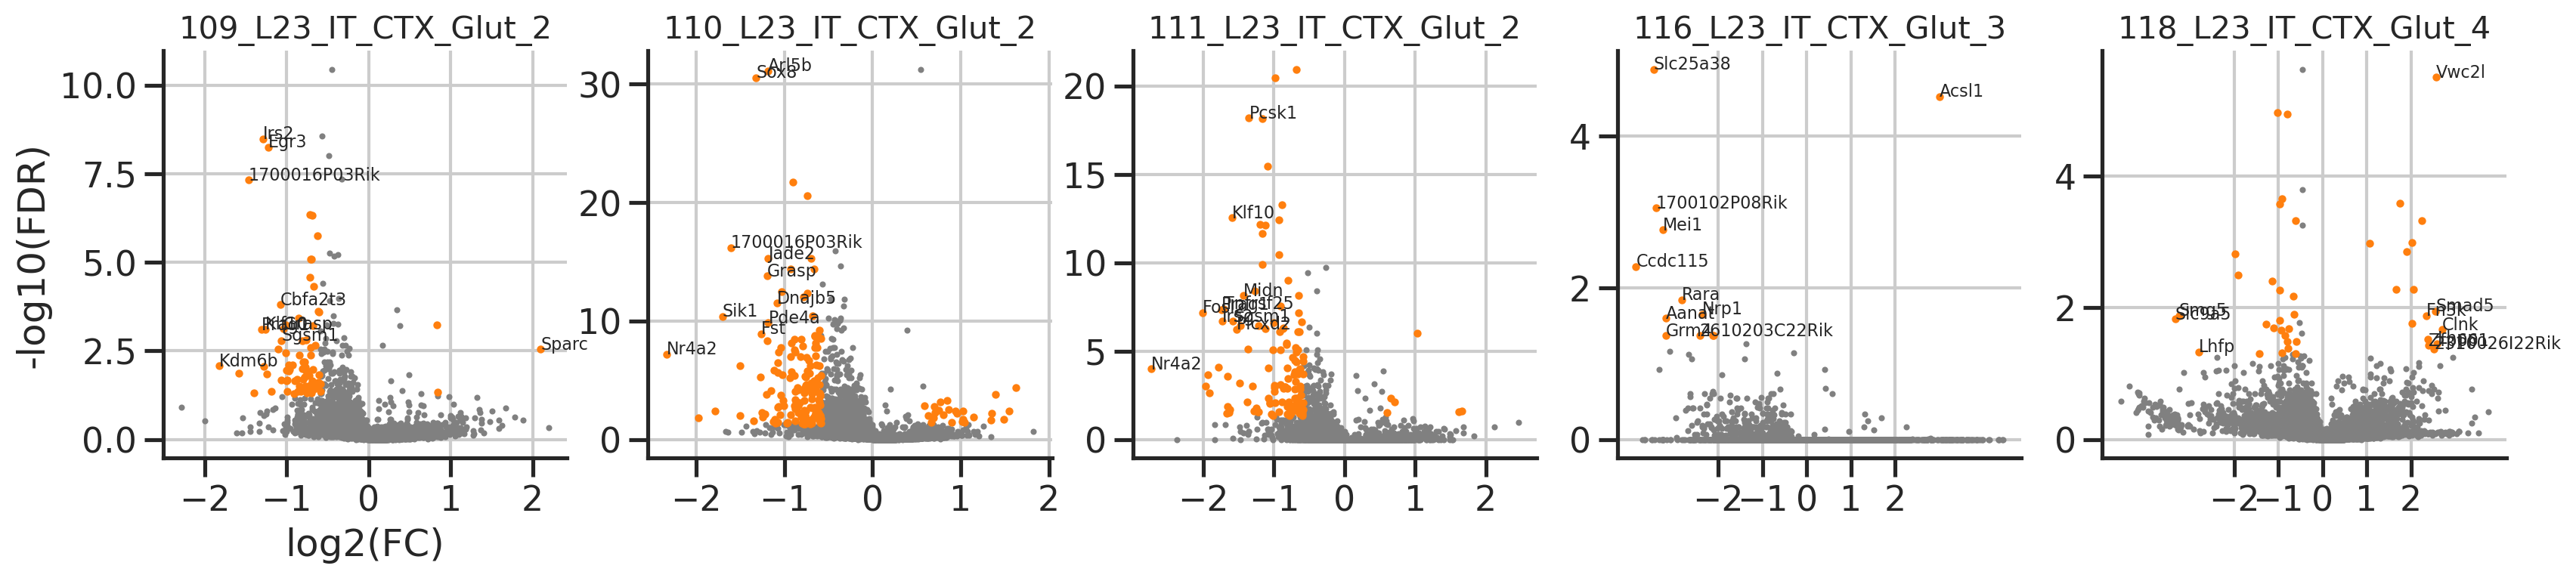

In [10]:
n = len(track_labels)

fig, axs = plt.subplots(1,n,figsize=(4*n,1*3.5)) # , sharey=True)
for i in range(n):
    ax = axs[i]
    df = df_list[i]
    df_sig = df_sig_list[i]
    title = track_labels[i]

    ax.scatter(df['l2fc'].values, df['l10q'].values, s=2, color='gray')
    ax.scatter(df_sig['l2fc'].values, df_sig['l10q'].values, s=5, color='C1')
    for gene, row in df_sig.sort_values('score', ascending=False).head(10).iterrows():
        x = row['l2fc']
        y = row['l10q']
        ax.text(x,y,gene, fontsize=8)
    sns.despine(ax=ax)
    ax.set_title(title, fontsize=15)
    ax.set_xticks([-2,-1,0,1,2])
    
axs[0].set_xlabel('log2(FC)')
axs[0].set_ylabel('-log10(FDR)')
plt.show()

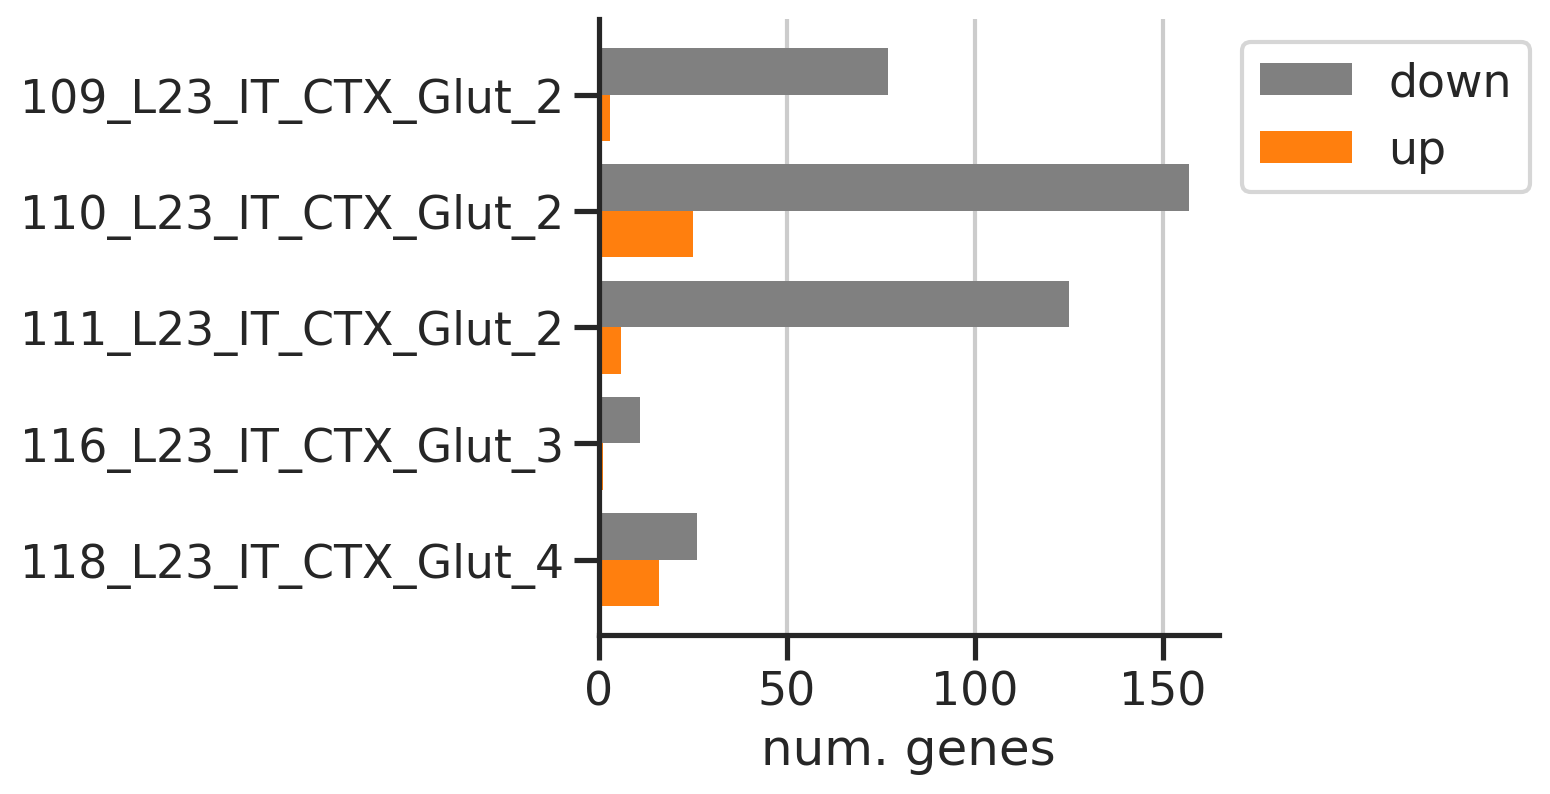

In [11]:

nums_sig = []
for i in range(n):
    df_sig = df_sig_list[i]
    # df_sig.groupby()plot.bar()
    nums_sig.append(df_sig.groupby('direction').size()) # .plot.bar()
    
nums_sig = pd.concat(nums_sig, axis=1).fillna(0) #names=track_labels)
nums_sig.columns = track_labels
fig, ax = plt.subplots(figsize=(4,4))
nums_sig.T.plot.barh(stacked=False, edgecolor='none', width=0.8, color=['gray', 'C1'], ax=ax)
sns.despine(ax=ax)
# ax.set_xticklabels(track_labels)
ax.legend(bbox_to_anchor=(1,1))
ax.invert_yaxis()
ax.grid(axis='y')
ax.set_xlabel('num. genes')
plt.show()


In [12]:
for res in res_list:
    print(res.loc['Vwc2l'])#['P21a', 'P21b', 'P21DRa', 'P21DRb'])

log2fc       0.606406
pval         0.088142
qval         0.428052
converged       False
P21DRa        0.17355
P21DRb        0.22483
P21a         0.131976
P21b         0.110876
Name: Vwc2l, dtype: object
log2fc       0.436505
pval          0.37272
qval         0.654918
converged        True
P21DRa       1.155964
P21DRb       0.850687
P21a         0.902383
P21b         0.592805
Name: Vwc2l, dtype: object
log2fc       1.924809
pval         0.219457
qval         0.999959
converged       False
P21DRa        0.43826
P21DRb       0.496009
P21a         0.124241
P21b         0.104368
Name: Vwc2l, dtype: object
log2fc       0.164717
pval         0.969749
qval              1.0
converged        True
P21DRa       1.338357
P21DRb       0.867427
P21a         1.146603
P21b         0.808355
Name: Vwc2l, dtype: object
log2fc       2.570272
pval              0.0
qval         0.000003
converged        True
P21DRa       0.507737
P21DRb       0.639891
P21a         0.116783
P21b         0.073179
Name: Vwc2l,

# cell level data

In [13]:
%%time
adata_raw = sc.read(f_raw)
adata_raw

CPU times: user 989 ms, sys: 7.5 s, total: 8.49 s
Wall time: 28.9 s


AnnData object with n_obs × n_vars = 89287 × 16567
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time'
    var: 'feature_types'
    layers: 'norm'

In [14]:
df_lbl = pd.read_csv(f_lbl)
df_lbl['label'] = df_lbl['label'].apply(lambda x: x.replace(' ', '_').replace('/', ''))
df_lbl

,label,conf
AAACCGAAGTTCCTGC-1-P21a-2023 Multiome-9-0,118_L23_IT_CTX_Glut_4,0.474420
AAACGCGCAATCATGT-1-P21a-2023 Multiome-9-0,109_L23_IT_CTX_Glut_2,1.000000
AAACGCGCAGTTGCGT-1-P21a-2023 Multiome-9-0,109_L23_IT_CTX_Glut_2,0.808598
AAACGCGCATTGTGTG-1-P21a-2023 Multiome-9-0,109_L23_IT_CTX_Glut_2,0.807582
AAAGCAAGTTGACTTC-1-P21a-2023 Multiome-9-0,118_L23_IT_CTX_Glut_4,0.603338
...,...,...
CTCACACTCCCGTTTA-1-P21DRa-2023 Multiome-10-0,110_L23_IT_CTX_Glut_2,0.801094
TAATGGTGTGGAAGGC-1-P21DRb-2023 Multiome-10-0,110_L23_IT_CTX_Glut_2,0.934366
AGCATCCCATGCATAT-1-P21DRa-2023 Multiome-10-0,110_L23_IT_CTX_Glut_2,0.746450
GGTCTTTGTTTACTTG-1-P21DRb-2023 Multiome-10-0,116_L23_IT_CTX_Glut_3,0.659059


In [15]:
adata = adata_raw[df_lbl.index].copy()
adata.obs = adata.obs.join(df_lbl)
adata

AnnData object with n_obs × n_vars = 6469 × 16567
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'label', 'conf'
    var: 'feature_types'
    layers: 'norm'

In [16]:
counts = adata.obs.groupby(['Age', 'label']).size().unstack().T
counts_freq = counts/counts.sum()
counts_freq

Age,P21,P21DR
label,,
109_L23_IT_CTX_Glut_2,0.360596,0.260573
110_L23_IT_CTX_Glut_2,0.332128,0.417058
111_L23_IT_CTX_Glut_2,0.164483,0.278665
116_L23_IT_CTX_Glut_3,0.011297,0.034539
118_L23_IT_CTX_Glut_4,0.131496,0.009164


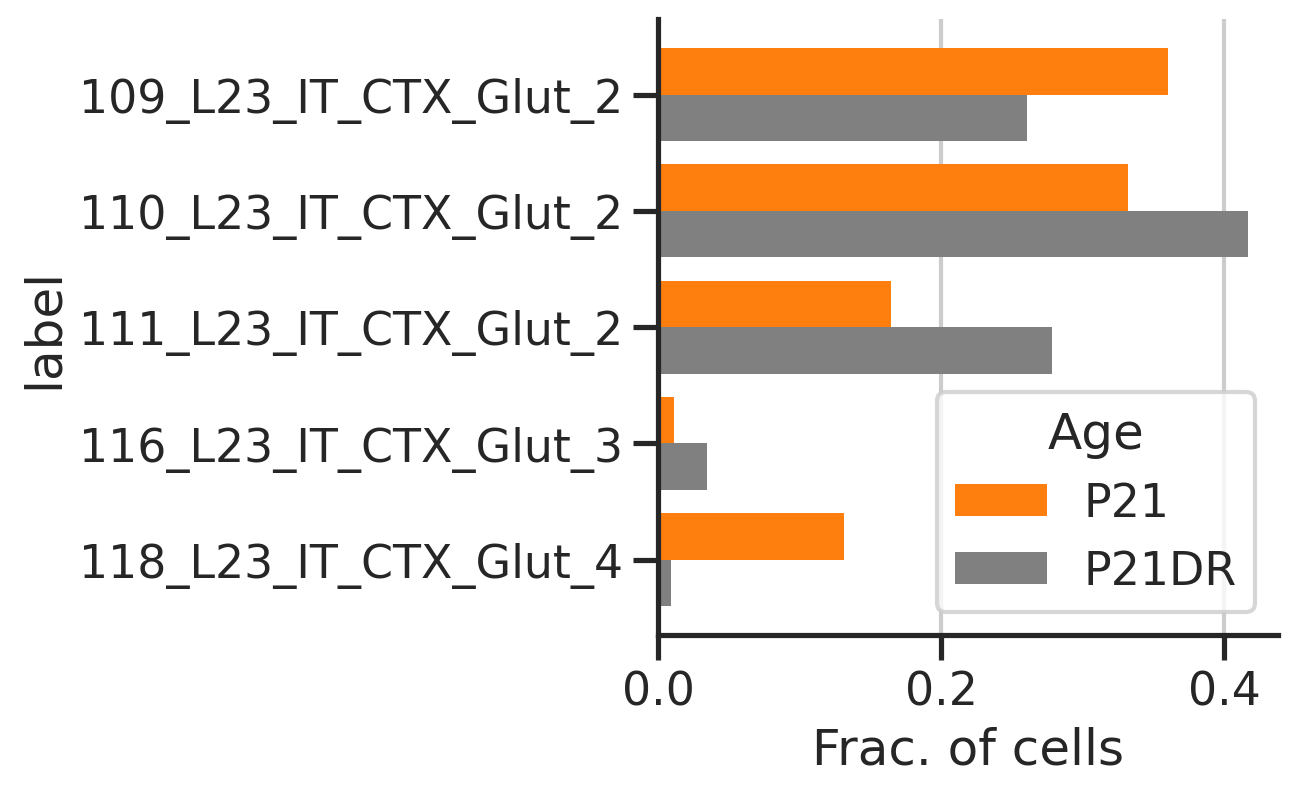

In [17]:

fig, ax = plt.subplots(figsize=(4,4))
counts_freq.plot.barh(width=0.8, edgecolor='none', color=['C1', 'gray'], ax=ax) # , legend=False)
ax.set_xlabel('Frac. of cells')
ax.invert_yaxis()
sns.despine(ax=ax)
ax.grid(axis='y')
plt.show()


<Axes: xlabel='Type', ylabel='label'>

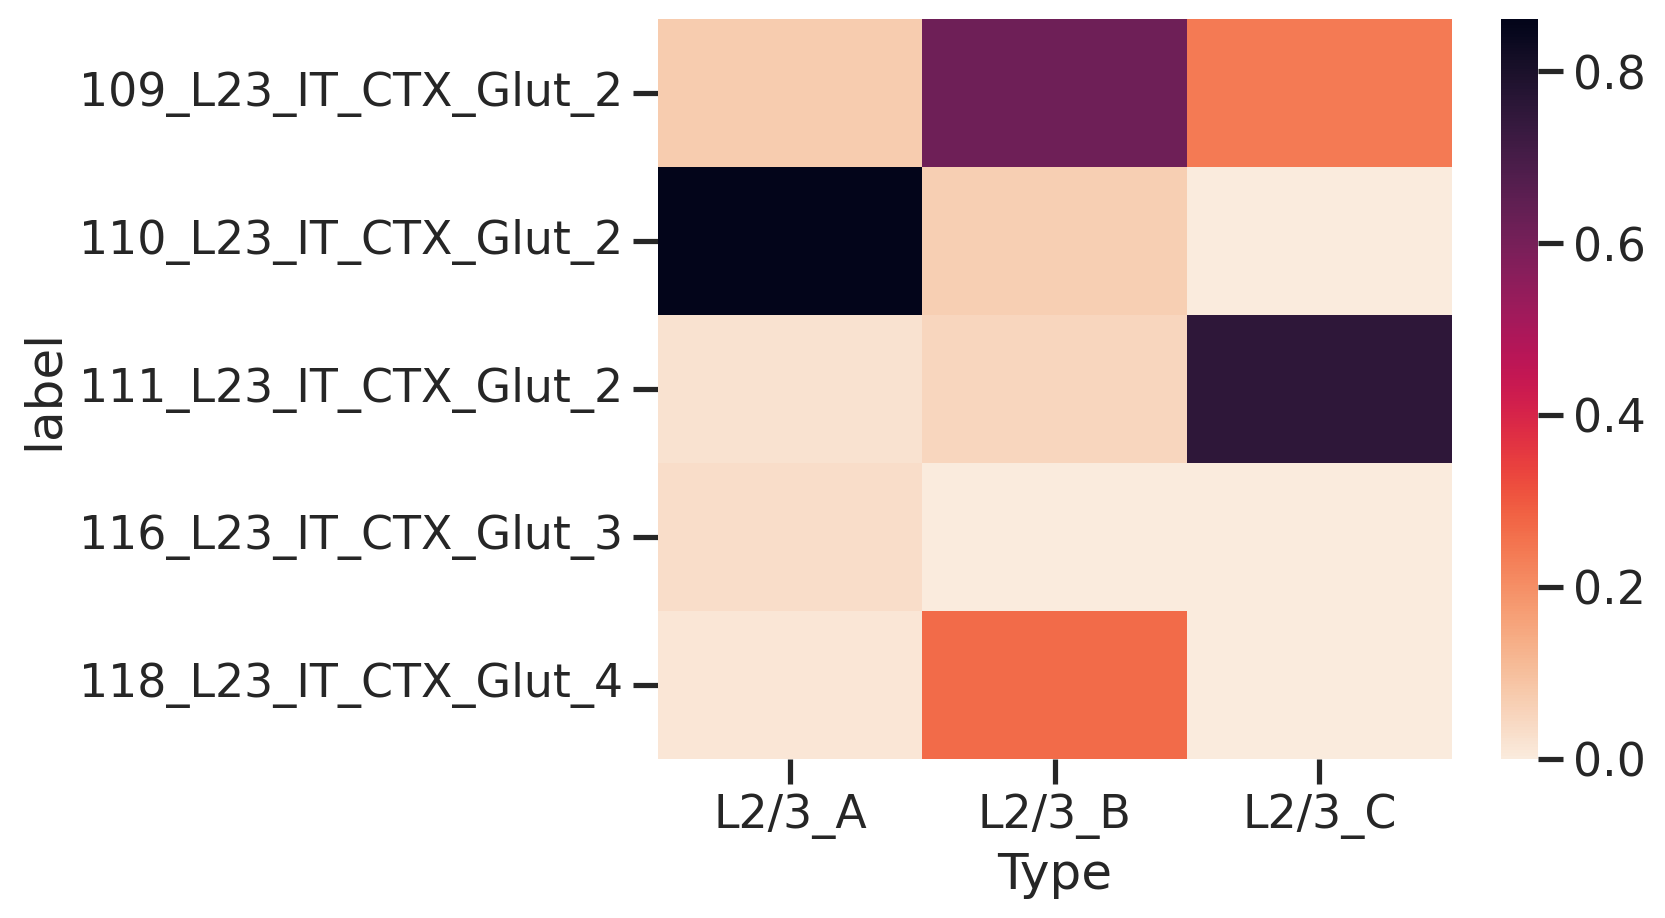

In [18]:
conf = adata[adata.obs['Age']=='P21'].obs.groupby(['label', 'Type']).size().unstack()#.T
conf = conf/conf.sum() 

sns.heatmap(conf, cmap='rocket_r')

<Axes: xlabel='Type', ylabel='label'>

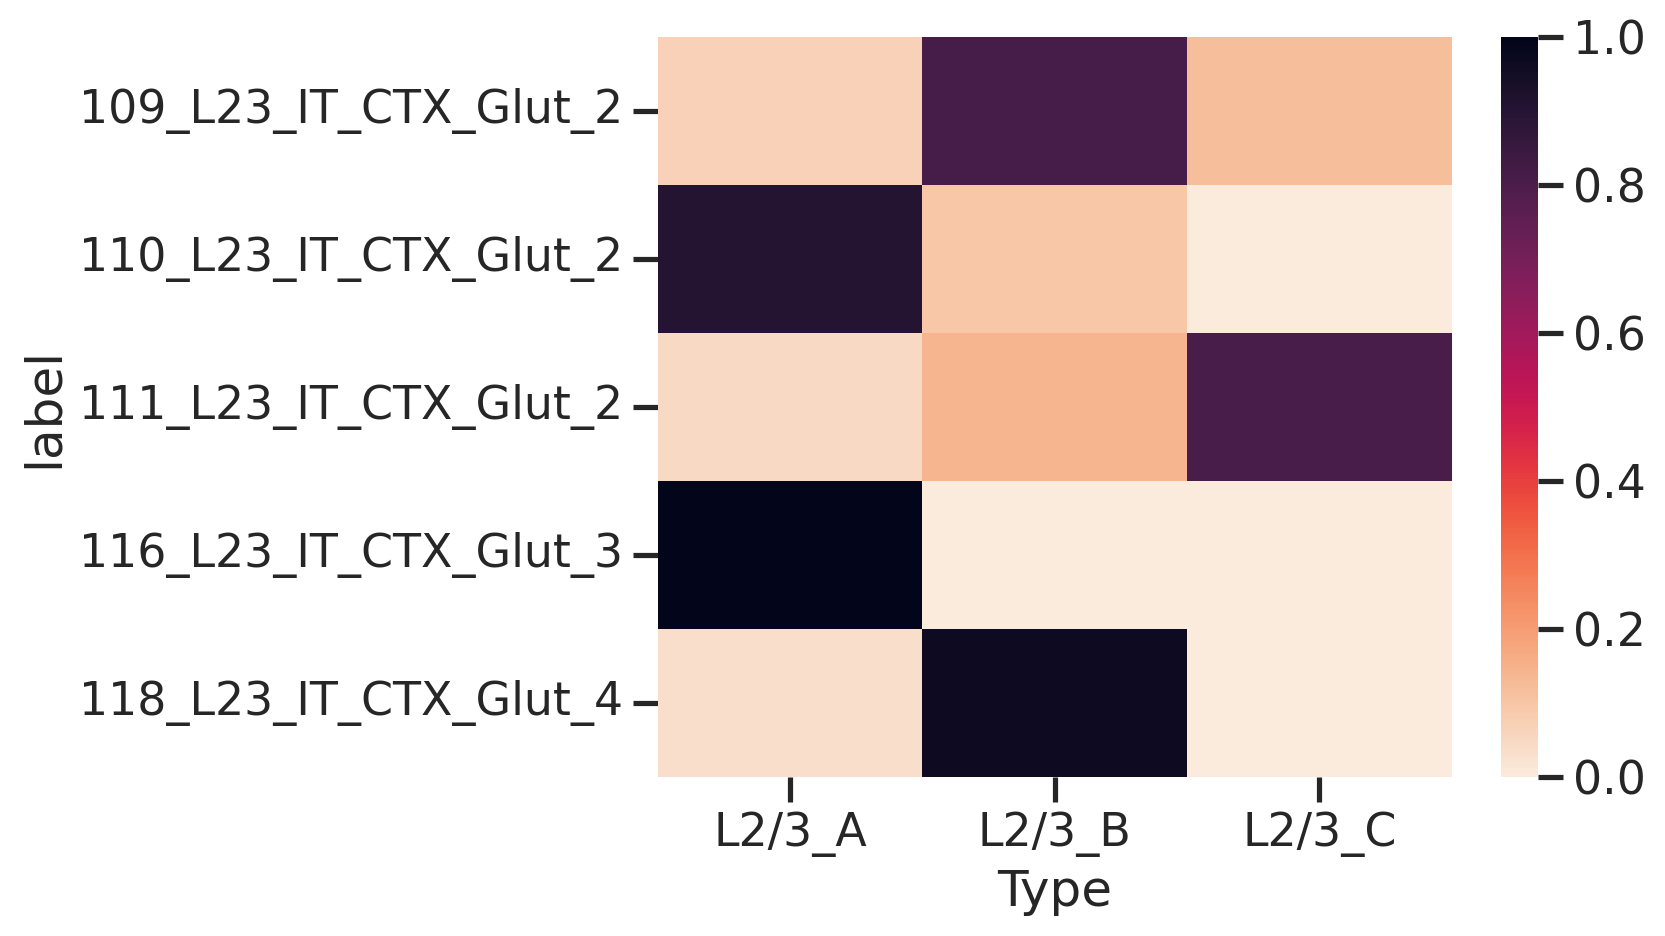

In [19]:
conf = adata[adata.obs['Age']=='P21'].obs.groupby(['label', 'Type']).size().unstack().T
conf = conf/conf.sum() 

sns.heatmap(conf.T, cmap='rocket_r')

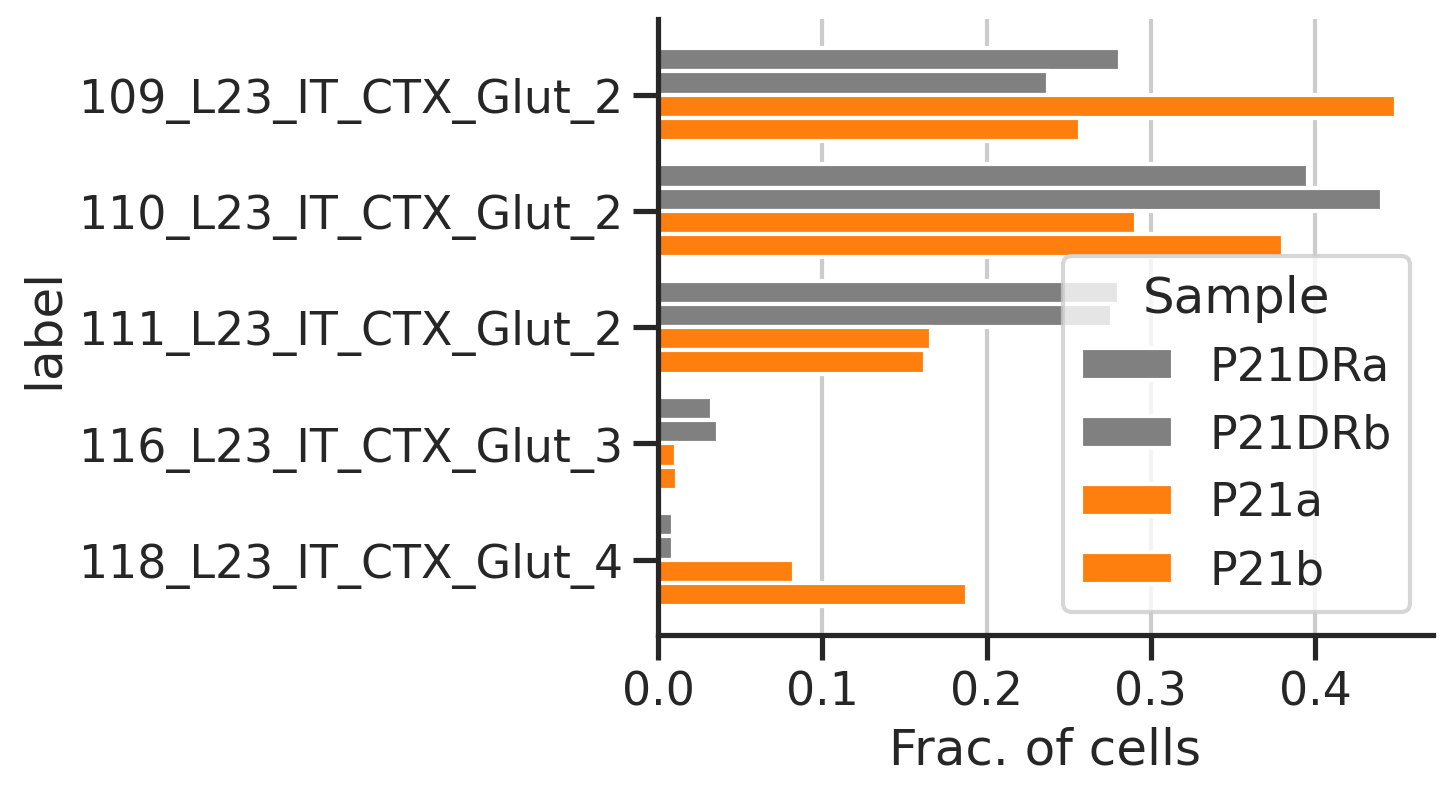

In [20]:
counts = adata.obs.groupby(['Sample', 'label']).size().unstack().T
counts_freq = counts/counts.sum()

fig, ax = plt.subplots(figsize=(5,4))
counts_freq.plot.barh(width=0.8, color=['gray']*2+['C1']*2, ax=ax) # , legend=False)
ax.set_xlabel('Frac. of cells')
ax.invert_yaxis()
sns.despine(ax=ax)
ax.grid(axis='y')
plt.show()

[INFO] There are 2 conditions. T-Test will be performed...
[INFO] Done!
CPU times: user 386 ms, sys: 18.6 ms, total: 404 ms
Wall time: 1.44 s


,baseline_props,mean_props_P21,mean_props_P21DR,prop_ratio,t_statistics,p_values,adjusted_p_values
clusters,,,,,,,
109_L23_IT_CTX_Glut_2,0.294791,0.353075,0.259351,1.361378,1.118540,0.348590,0.348590
110_L23_IT_CTX_Glut_2,0.388004,0.335628,0.418305,0.802351,-1.874645,0.162244,0.202805
111_L23_IT_CTX_Glut_2,0.239604,0.164357,0.278532,0.590082,-13.783981,0.001067,0.002669
116_L23_IT_CTX_Glut_3,0.026588,0.011331,0.034633,0.327168,-16.066791,0.000692,0.002669
118_L23_IT_CTX_Glut_4,0.051013,0.135610,0.009179,14.774344,6.917976,0.007267,0.012112


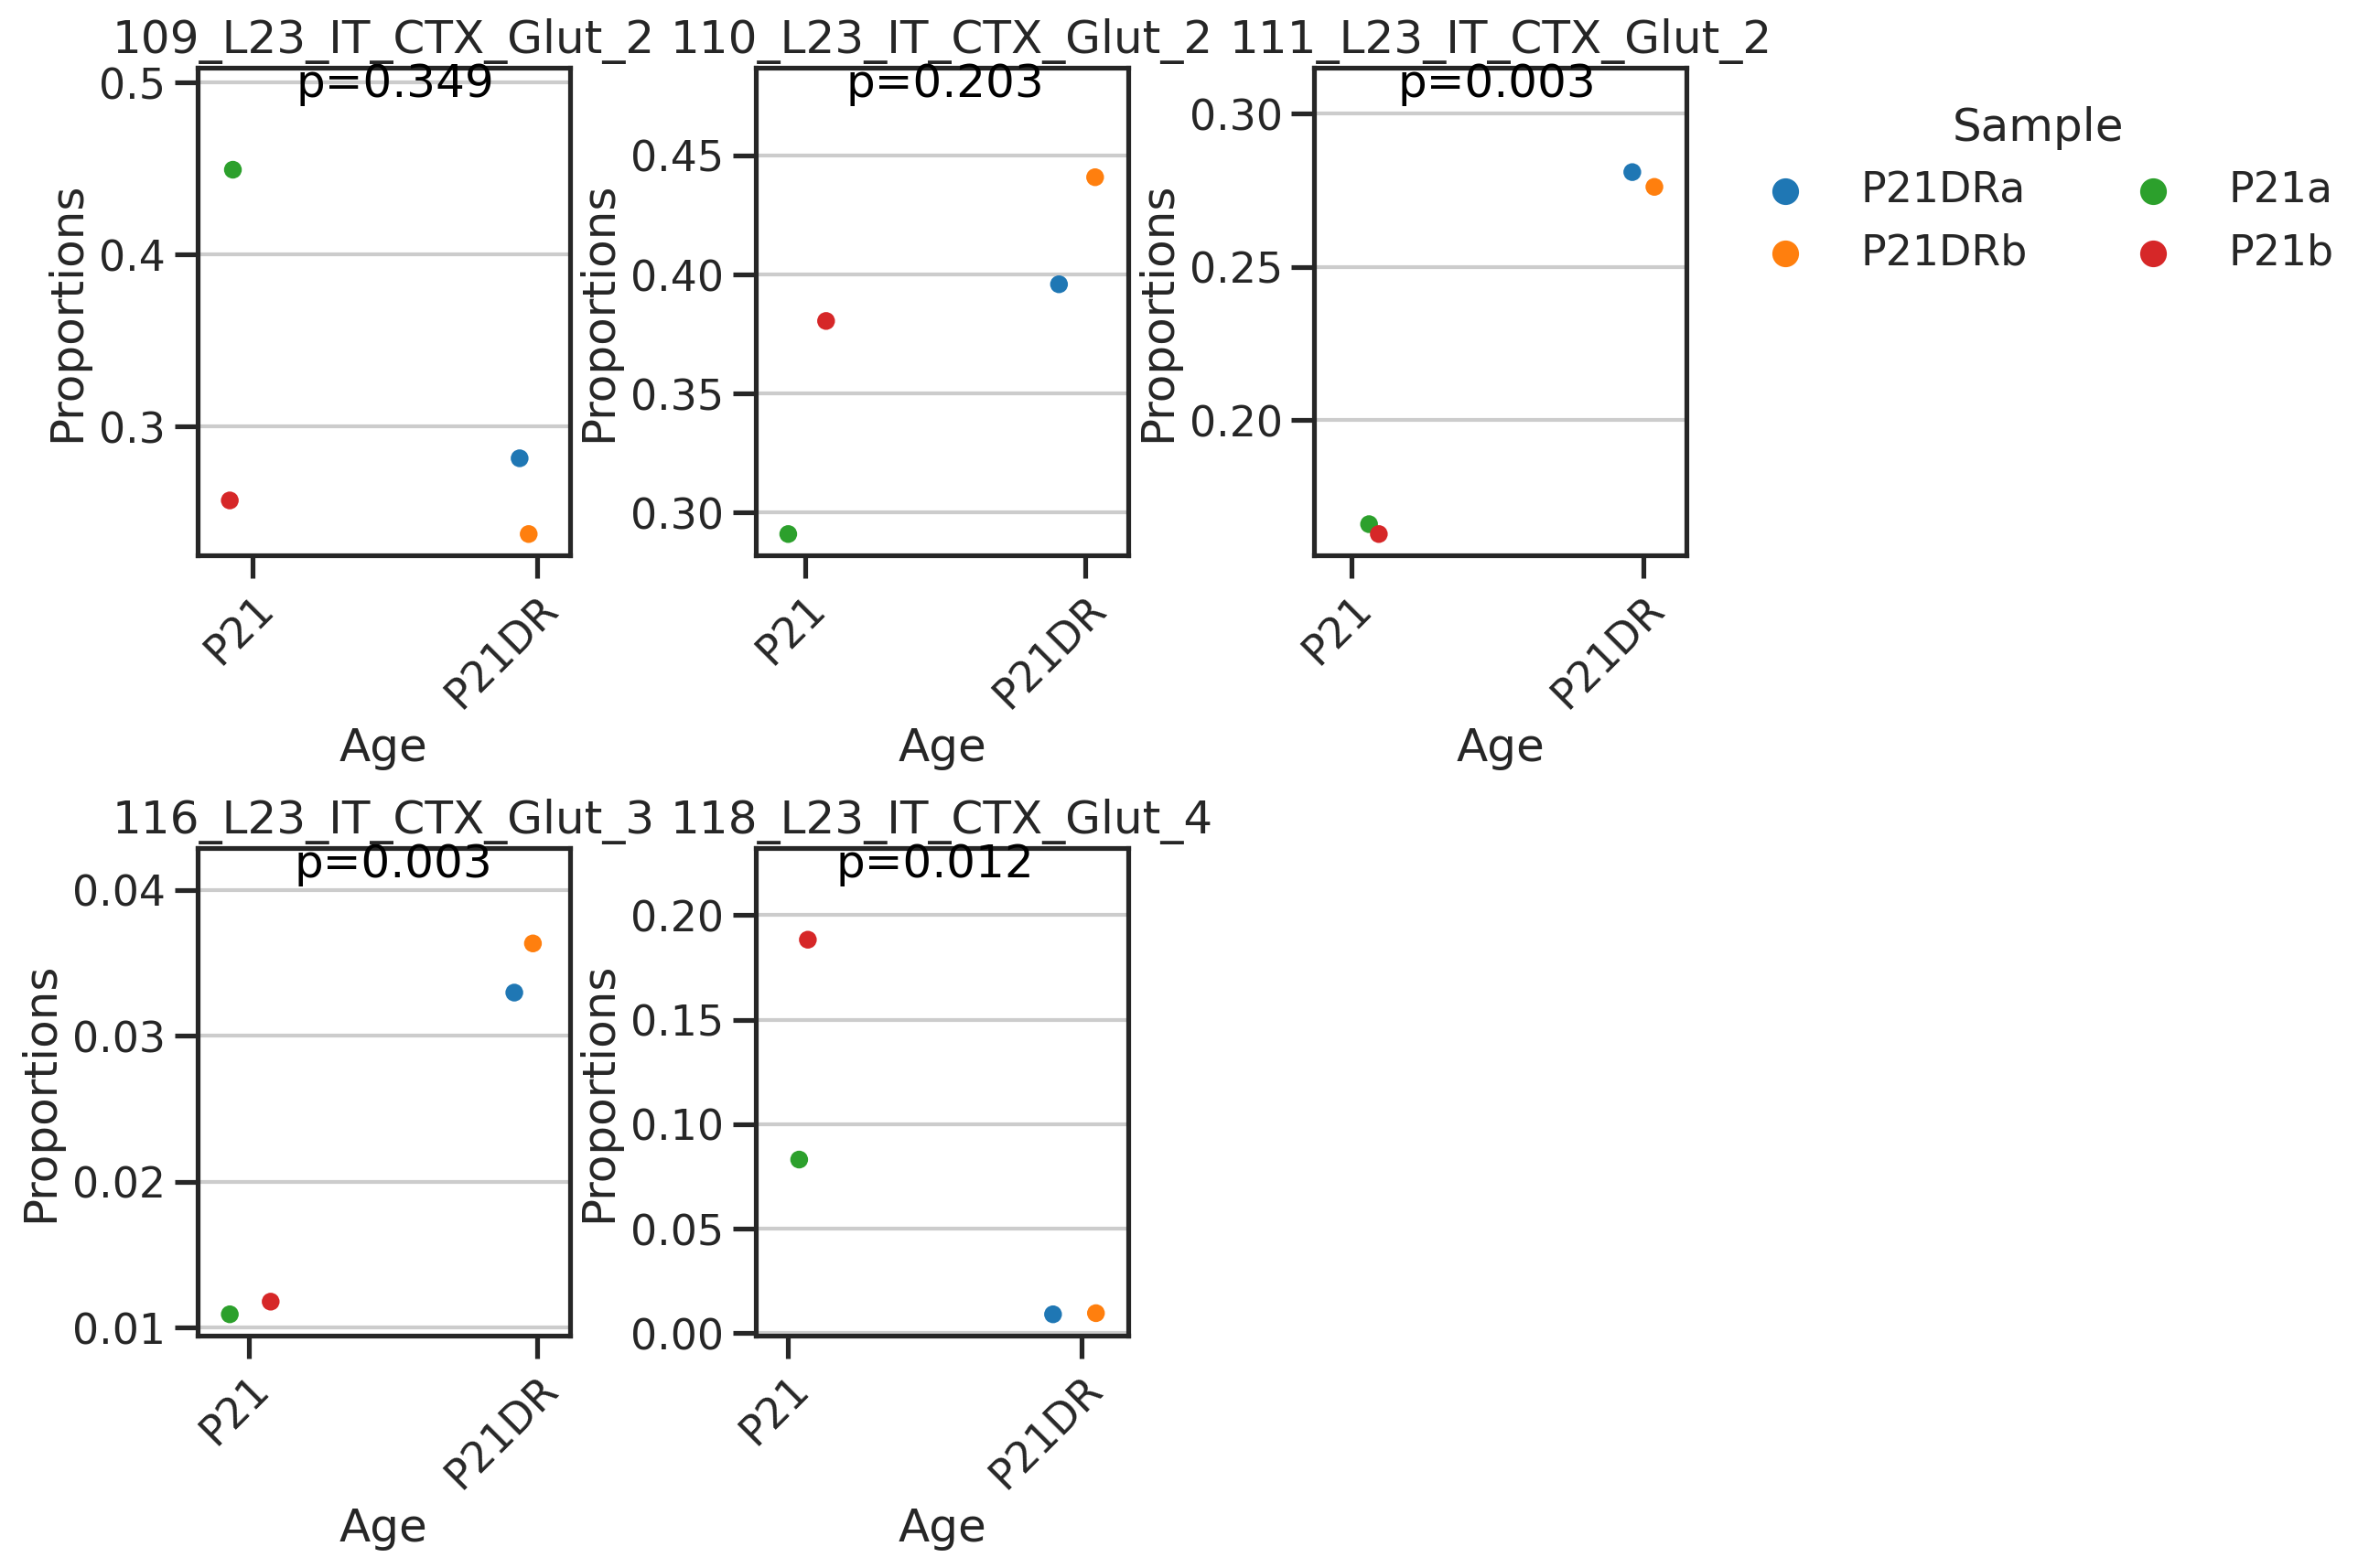

In [21]:
%%time
from scanpro import scanpro

# 2. Run the proportion analysis
# Note: If samples_col=None, Scanpro runs the bootstrapping method for unreplicated data.
out = scanpro(adata, 
              clusters_col='label',   # Column with cell type/cluster labels
              conds_col='Age',      # Column with experimental groups (e.g., Control vs Treated)
              samples_col='Sample',       # Column with replicate/sample IDs
              transform='logit')          # 'logit' or 'arcsin' transformation


# 4. Visualize the shifts
# Generates plots showing proportions across conditions
out.plot(kind='stripplot')  # Options: 'stripplot', 'barplot', or 'boxplot'

out.results

In [19]:
offset = 1e-2
scale = 1e4

mat = np.array(adata.X.todense())/adata.obs['total_counts'].values.reshape(-1,1)*scale
adata.layers['cp10k'] = mat
adata.layers['log2cp10k'] = np.log2(1+mat)
adata

AnnData object with n_obs × n_vars = 6469 × 16567
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'label', 'conf'
    var: 'feature_types'
    layers: 'norm', 'cp10k', 'log2cp10k'

In [20]:
sample_orders = adata.obs['Sample'].astype(str).unique()
print(sample_orders)

palette = {
    'P21': 'C1', 
    'P21DR': 'gray', 
    }

['P21a' 'P21b' 'P21DRa' 'P21DRb']


In [21]:
def plot_one_gene_ax(gene, ax, adata, df_stats):
    """
    """
    dfplot = adata.obs[['Age', 'Sample', 'Subclass']].copy()
    dfplot[gene] = np.array(adata[:,gene].layers['log2cp10k']).reshape(-1,)
    stats = df_stats.loc[gene]

    sns.violinplot(data=dfplot, x='Sample', hue='Age', palette=palette,
                   order=sample_orders, 
                   dodge=False, y=gene, 
                   cut=0, 
                   ax=ax)
    ax.set_title(f'{gene}')

    ax.text(0.05, 0.95, f'q={np.power(10, -stats.l10q):.2g}, l2fc={stats.l2fc:.2g}, conv {stats.converged}', 
            ha='left',
            transform=ax.transAxes, 
            fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('log2(1+cp10k)', fontsize=12)
    sns.despine(ax=ax)
    return dfplot

In [22]:
adata.obs['label'].unique(), track_labels

(array(['118_L23_IT_CTX_Glut_4', '109_L23_IT_CTX_Glut_2',
        '111_L23_IT_CTX_Glut_2', '110_L23_IT_CTX_Glut_2',
        '116_L23_IT_CTX_Glut_3'], dtype=object),
 array(['109_L23_IT_CTX_Glut_2', '110_L23_IT_CTX_Glut_2',
        '111_L23_IT_CTX_Glut_2', '116_L23_IT_CTX_Glut_3',
        '118_L23_IT_CTX_Glut_4'], dtype='<U21'))

In [23]:
adata_list = []
for track_label in track_labels:
    adata_subclass = adata[adata.obs['label']==track_label]
    adata_list.append(adata_subclass)

In [24]:
adata_list

[View of AnnData object with n_obs × n_vars = 1907 × 16567
     obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'label', 'conf'
     var: 'feature_types'
     layers: 'norm', 'cp10k', 'log2cp10k',
 View of AnnData object with n_obs × n_vars = 2510 × 16567
     obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'label', 'conf'
     var: 'feature_types'
     layers: 'norm', 'cp10k', 'log2cp10k',
 View of AnnData object with n_obs × n_vars = 1550 × 16567
     obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct

In [25]:
df_raw_list[0]

,log2fc,pval,qval,converged,P21DRa,P21DRb,P21a,P21b,l2fc,l10q
gene,,,,,,,,,,
Xkr4,0.146112,0.502758,0.824008,True,5.955652,6.661402,5.775247,5.410131,0.146112,0.084069
Gm1992,-0.533011,0.152029,0.536893,True,0.100924,0.153792,0.194363,0.160985,-0.533011,0.270112
Mrpl15,0.031781,0.712368,0.912294,True,0.128292,0.190499,0.135812,0.183449,0.031781,0.039865
Tcea1,0.120039,0.674600,0.901345,False,0.575940,0.534574,0.510152,0.518181,0.120039,0.045109
Rgs20,0.039325,0.614354,0.877306,True,1.507648,1.155408,1.194666,1.574607,0.039325,0.056849
...,...,...,...,...,...,...,...,...,...,...
Csf2ra,-0.226377,0.091698,0.434677,False,0.203456,0.188491,0.226404,0.244029,-0.226377,0.361834
Vamp7,0.079529,0.944601,0.982298,True,0.085029,0.103177,0.076124,0.110223,0.079529,0.007757
Tmlhe,0.121944,0.661090,0.896837,False,0.241521,0.253868,0.212571,0.253517,0.121944,0.047287


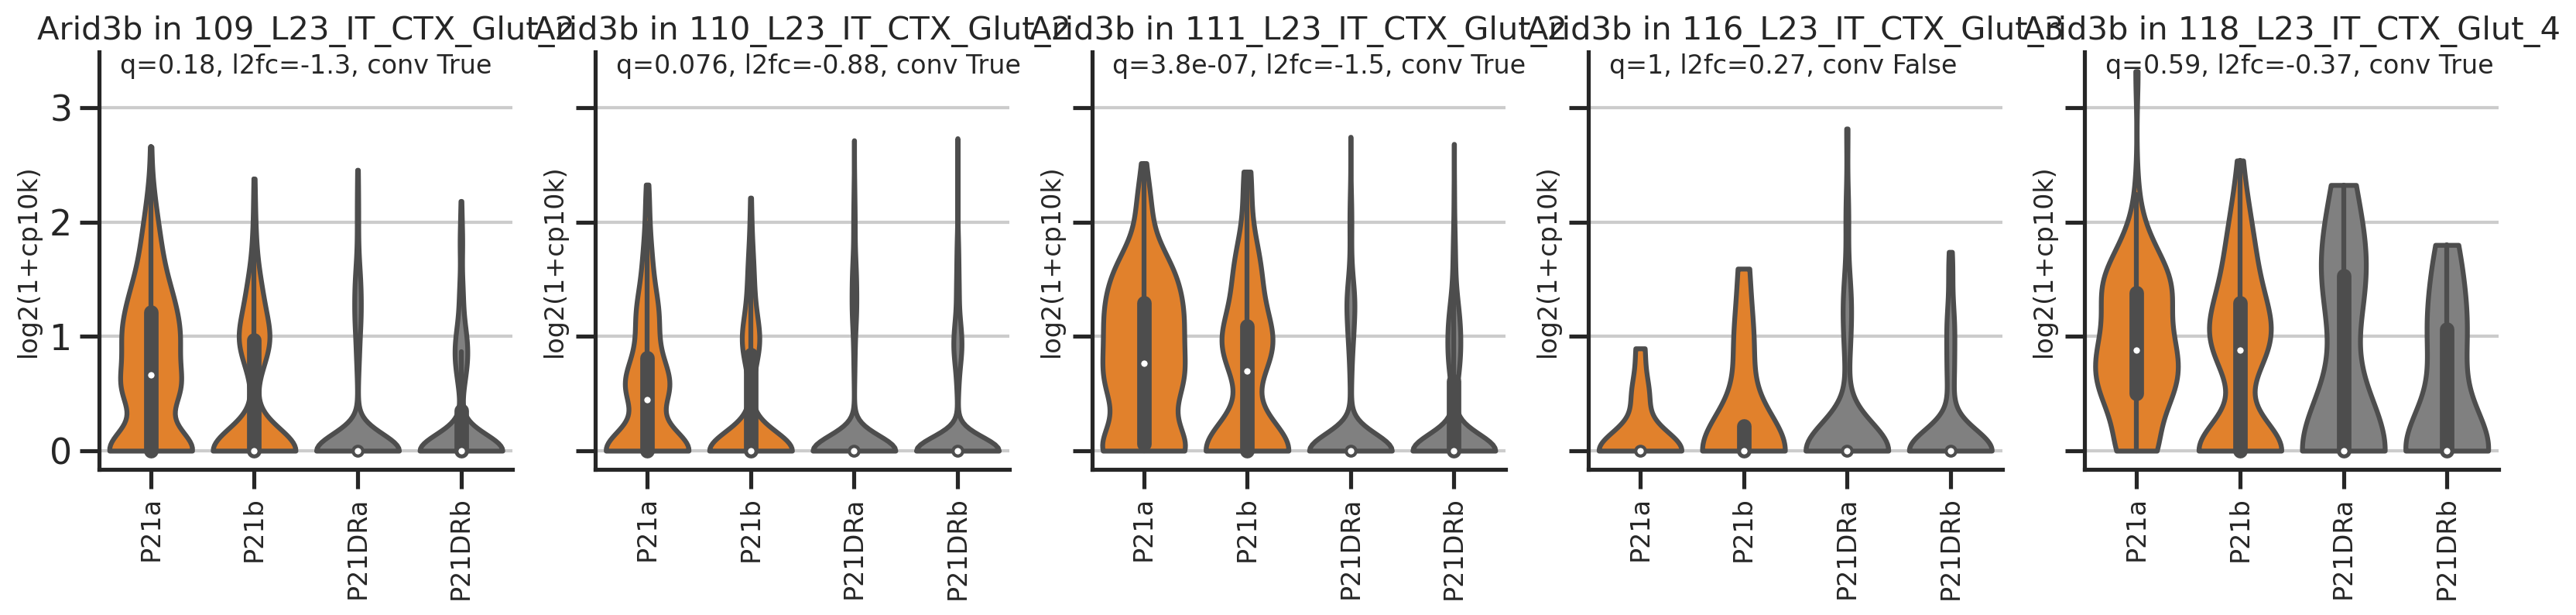

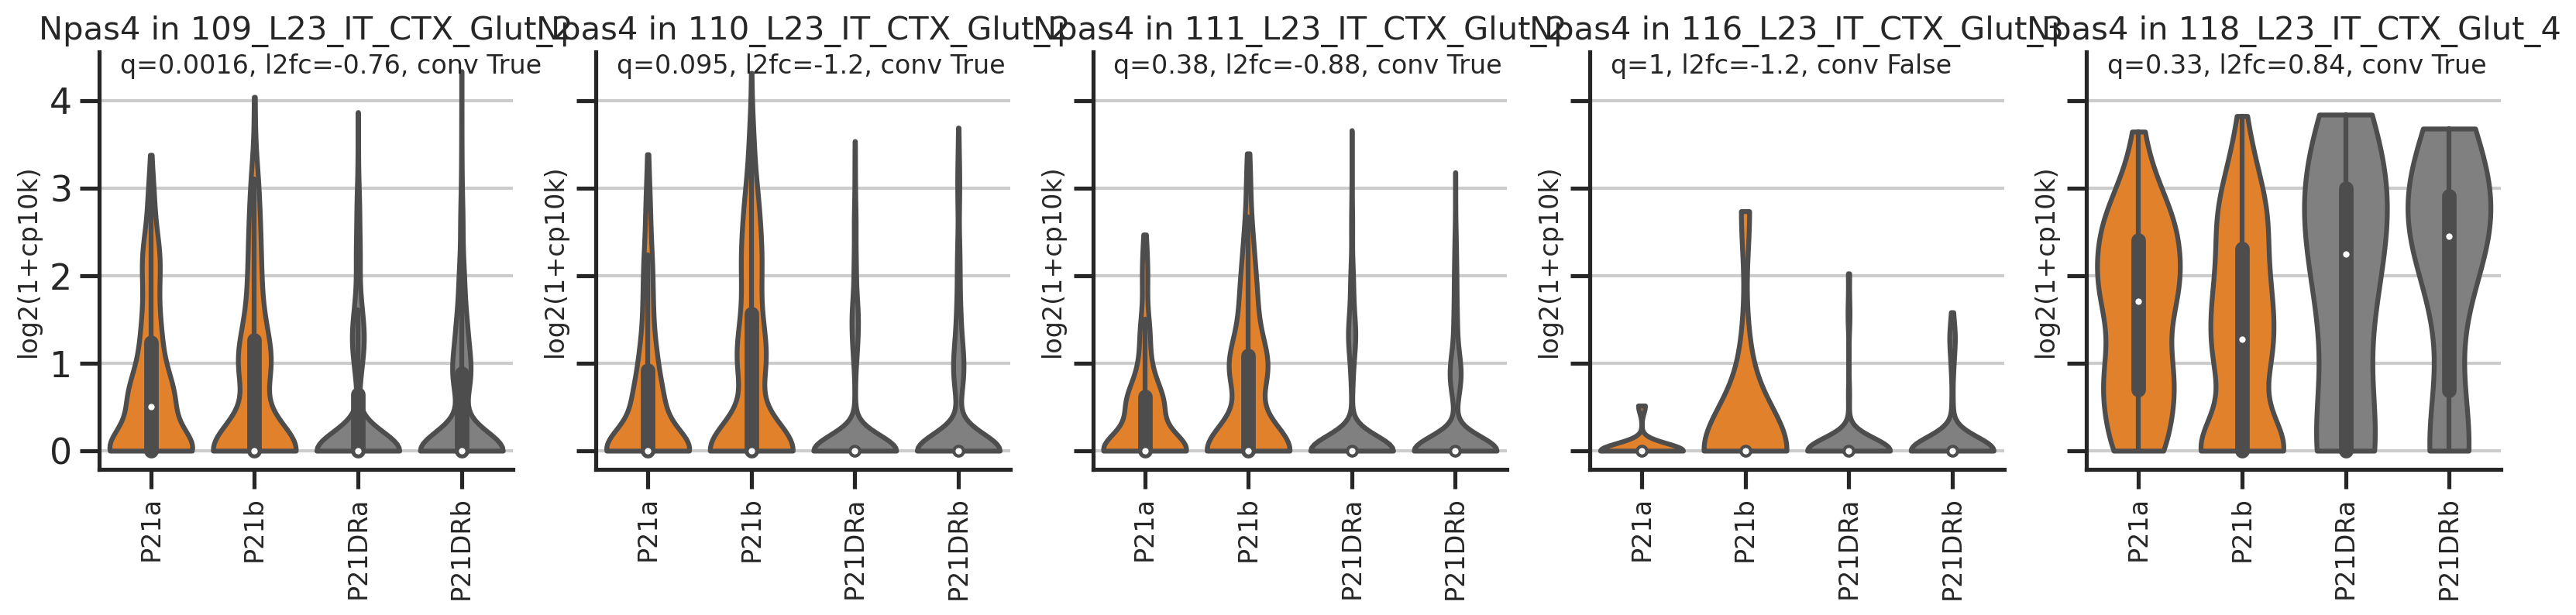

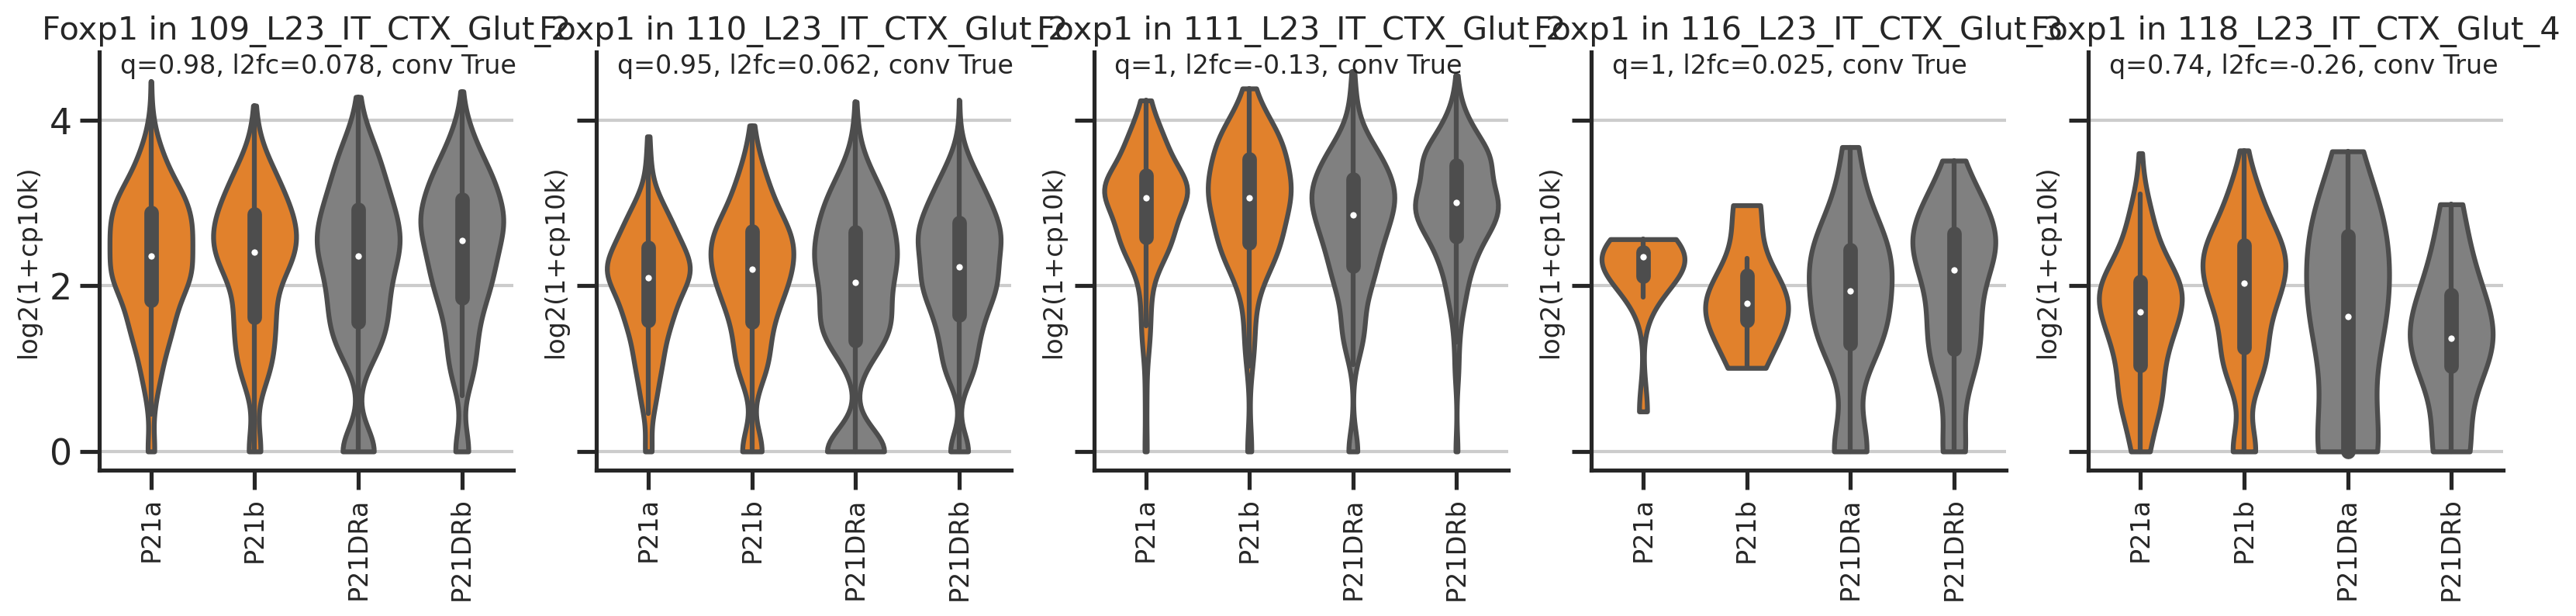

KeyError: 'Nptx2'

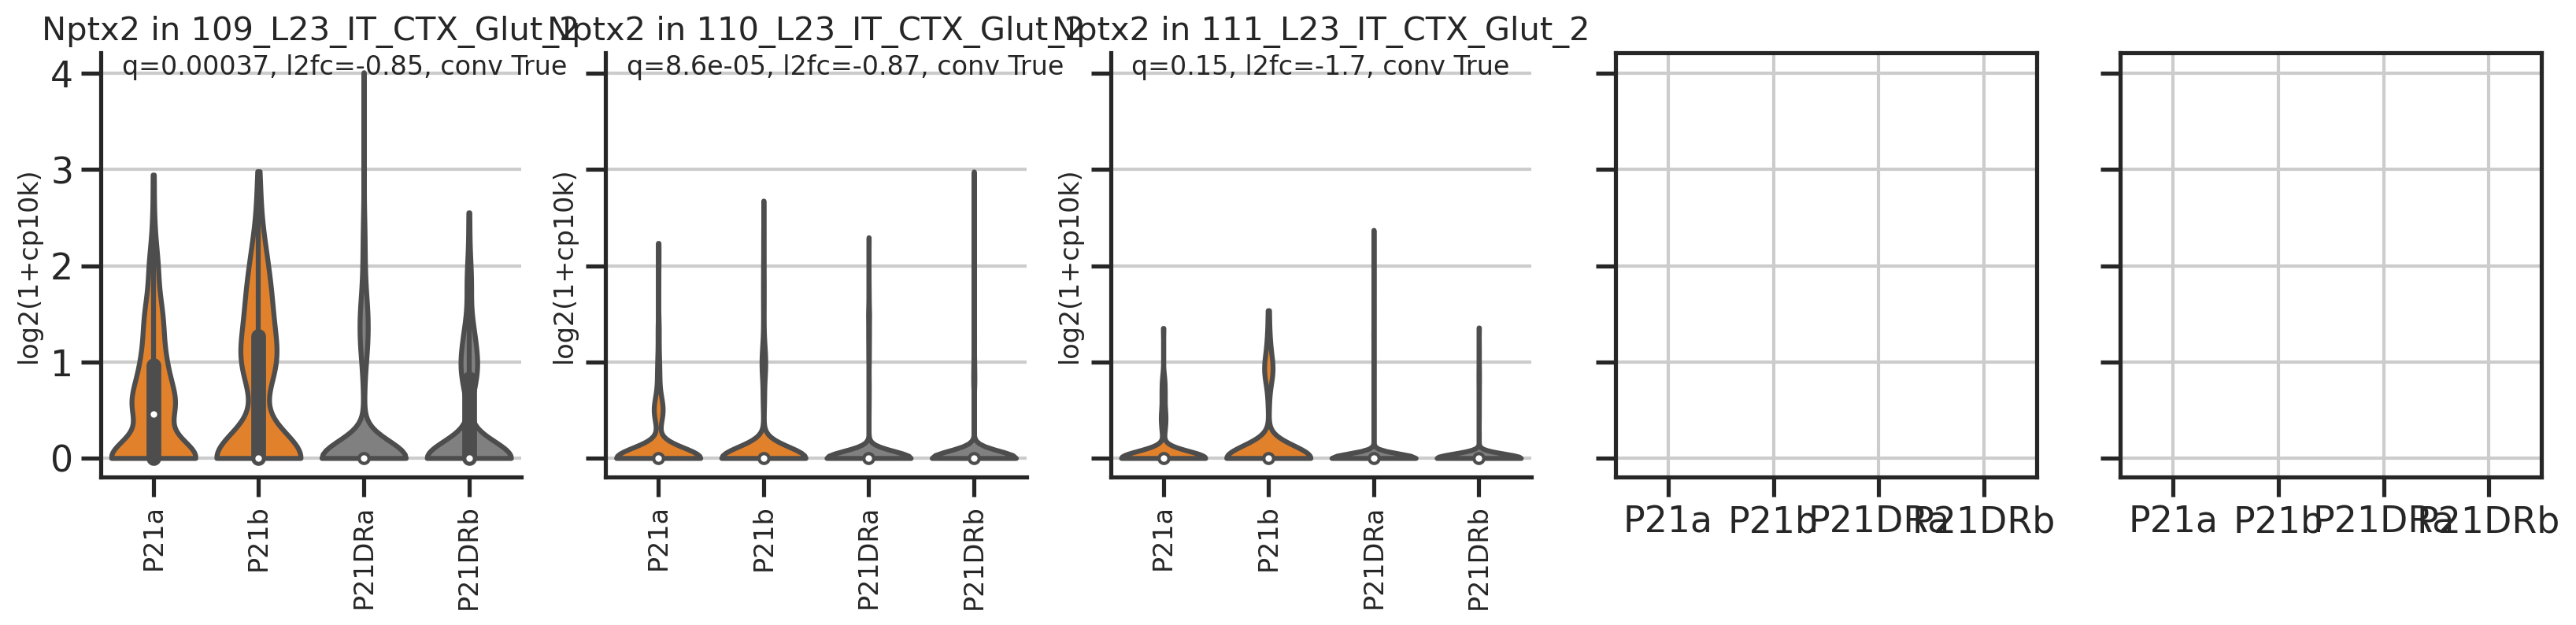

In [26]:
n = len(track_labels)
for gene in ['Arid3b', 'Npas4', 'Foxp1', 'Nptx2']:
    fig, axs = plt.subplots(1, n, figsize=(4*n,3.5), sharey=True, sharex=True)
    for i in range(n):
        ax = axs[i]
        df = df_raw_list[i]
        adata_subclass = adata_list[i]
        track_label = track_labels[i]
        
        dfplot = plot_one_gene_ax(gene, ax, adata_subclass, df)
        ax.set_title(f'{gene} in {track_label}', fontsize=15)
        ax.legend_.remove()

    plt.show()

# shared vs different